## Handwrite digits

In [17]:
from sklearn import datasets
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [25]:

from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
# Prepara i dati (X sono le immagini, y sono le etichette)
X = digits.images.reshape((len(digits.images), -1))  # Appiattisce le immagini 8x8 in vettori 1D
y = digits.target
n_components = 2
# Scegli il numero di vicini da considerare (parametro importante da regolare)
n_neighbors = 5

print(f"Inizializzazione di Isomap con n_components={n_components} e n_neighbors={n_neighbors}")
isomap = Isomap(n_neighbors=n_neighbors,
                n_components=n_components,
                n_jobs=-1)
X_iso = isomap.fit_transform(X)

X_iso_train, X_iso_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dimensioni del training set: {X_iso_train.shape}")
print(f"Dimensioni del test set: {X_iso_test.shape}")
print(X[0], X_iso[0])

Inizializzazione di Isomap con n_components=2 e n_neighbors=5


c:\Users\domen\Desktop\my_env\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\domen\Desktop\my_env\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Dimensioni del training set: (1437, 64)
Dimensioni del test set: (360, 64)
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.] [164.62462575  28.93626891]


C:\Users\domen\AppData\Local\Temp\ipykernel_4284\403409189.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  scatter = plt.scatter(X_iso[:, 0], X_iso[:, 1], c=y, cmap=plt.cm.get_cmap("jet", 10), edgecolor='k', s=40)


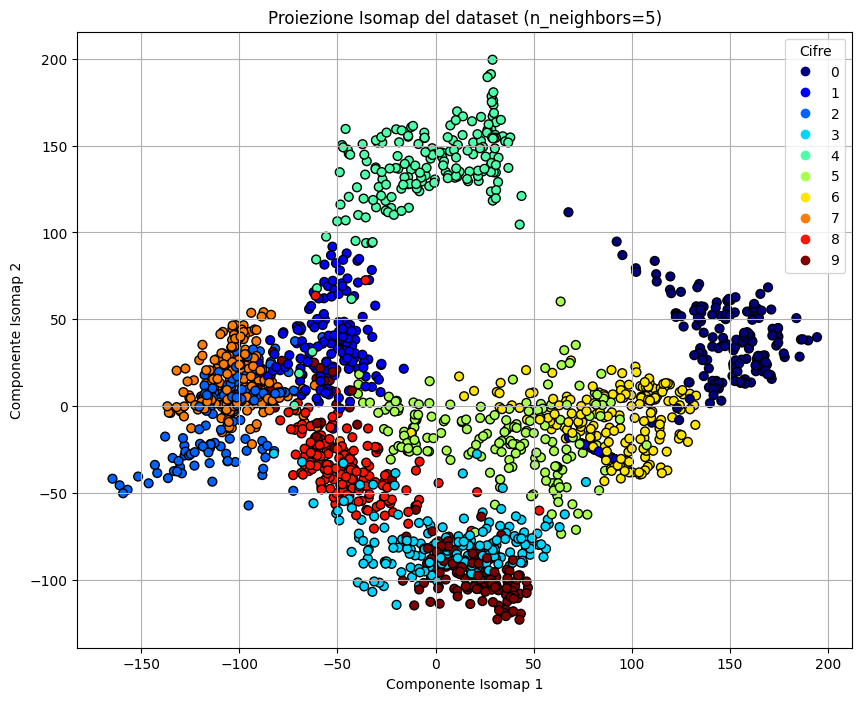

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_iso[:, 0], X_iso[:, 1], c=y, cmap=plt.cm.get_cmap("jet", 10), edgecolor='k', s=40)
plt.title(f'Proiezione Isomap del dataset (n_neighbors={n_neighbors})')
plt.xlabel('Componente Isomap 1')
plt.ylabel('Componente Isomap 2')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Cifre")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Create and train the model
clf = LogisticRegression(solver='sag', max_iter=1000)
clf.fit(X_iso_train, y_train)

# Make predictions
y_pred = clf.predict(X_iso_test)

# Print performance metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))